# Modelling

In [43]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [44]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [45]:
import pandas as pd
df = pd.read_csv(r"C:\Users\DELL\Downloads\data_for_predictions.csv")
train_df=df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)


(14606, 62)
(14606,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(10954, 62)
(10954,)
(3652, 62)
(3652,)


In [59]:
df.drop(columns = 'Unnamed: 0', inplace=True)  #drop the unnamed column

KeyError: "['Unnamed: 0'] not found in axis"

In [48]:
# model traning

In [49]:
model=RandomForestClassifier(
    n_estimators=1000
)
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=1000)

In [50]:
#Evaluation 

In [51]:
predictions = model.predict(X_test)
tn,fp,fn,tp = metrics.confusion_matrix(y_test,predictions).ravel()

In [52]:
y_test.value_counts()

churn
0    3286
1     366
Name: count, dtype: int64

In [53]:
print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"True negatives: {tn}")
print(f"False negatives; {fn}\n")

print(f"Accuracy: {metrics.accuracy_score(y_test, predictions)}")
print(f"Precision: {metrics.precision_score(y_test, predictions)}")
print(f"Recall: {metrics.recall_score(y_test, predictions)}")

True positives: 16
False positives: 3
True negatives: 3283
False negatives; 350

Accuracy: 0.9033406352683461
Precision: 0.8421052631578947
Recall: 0.04371584699453552


In [54]:
# model understanding

In [55]:
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=True).reset_index()


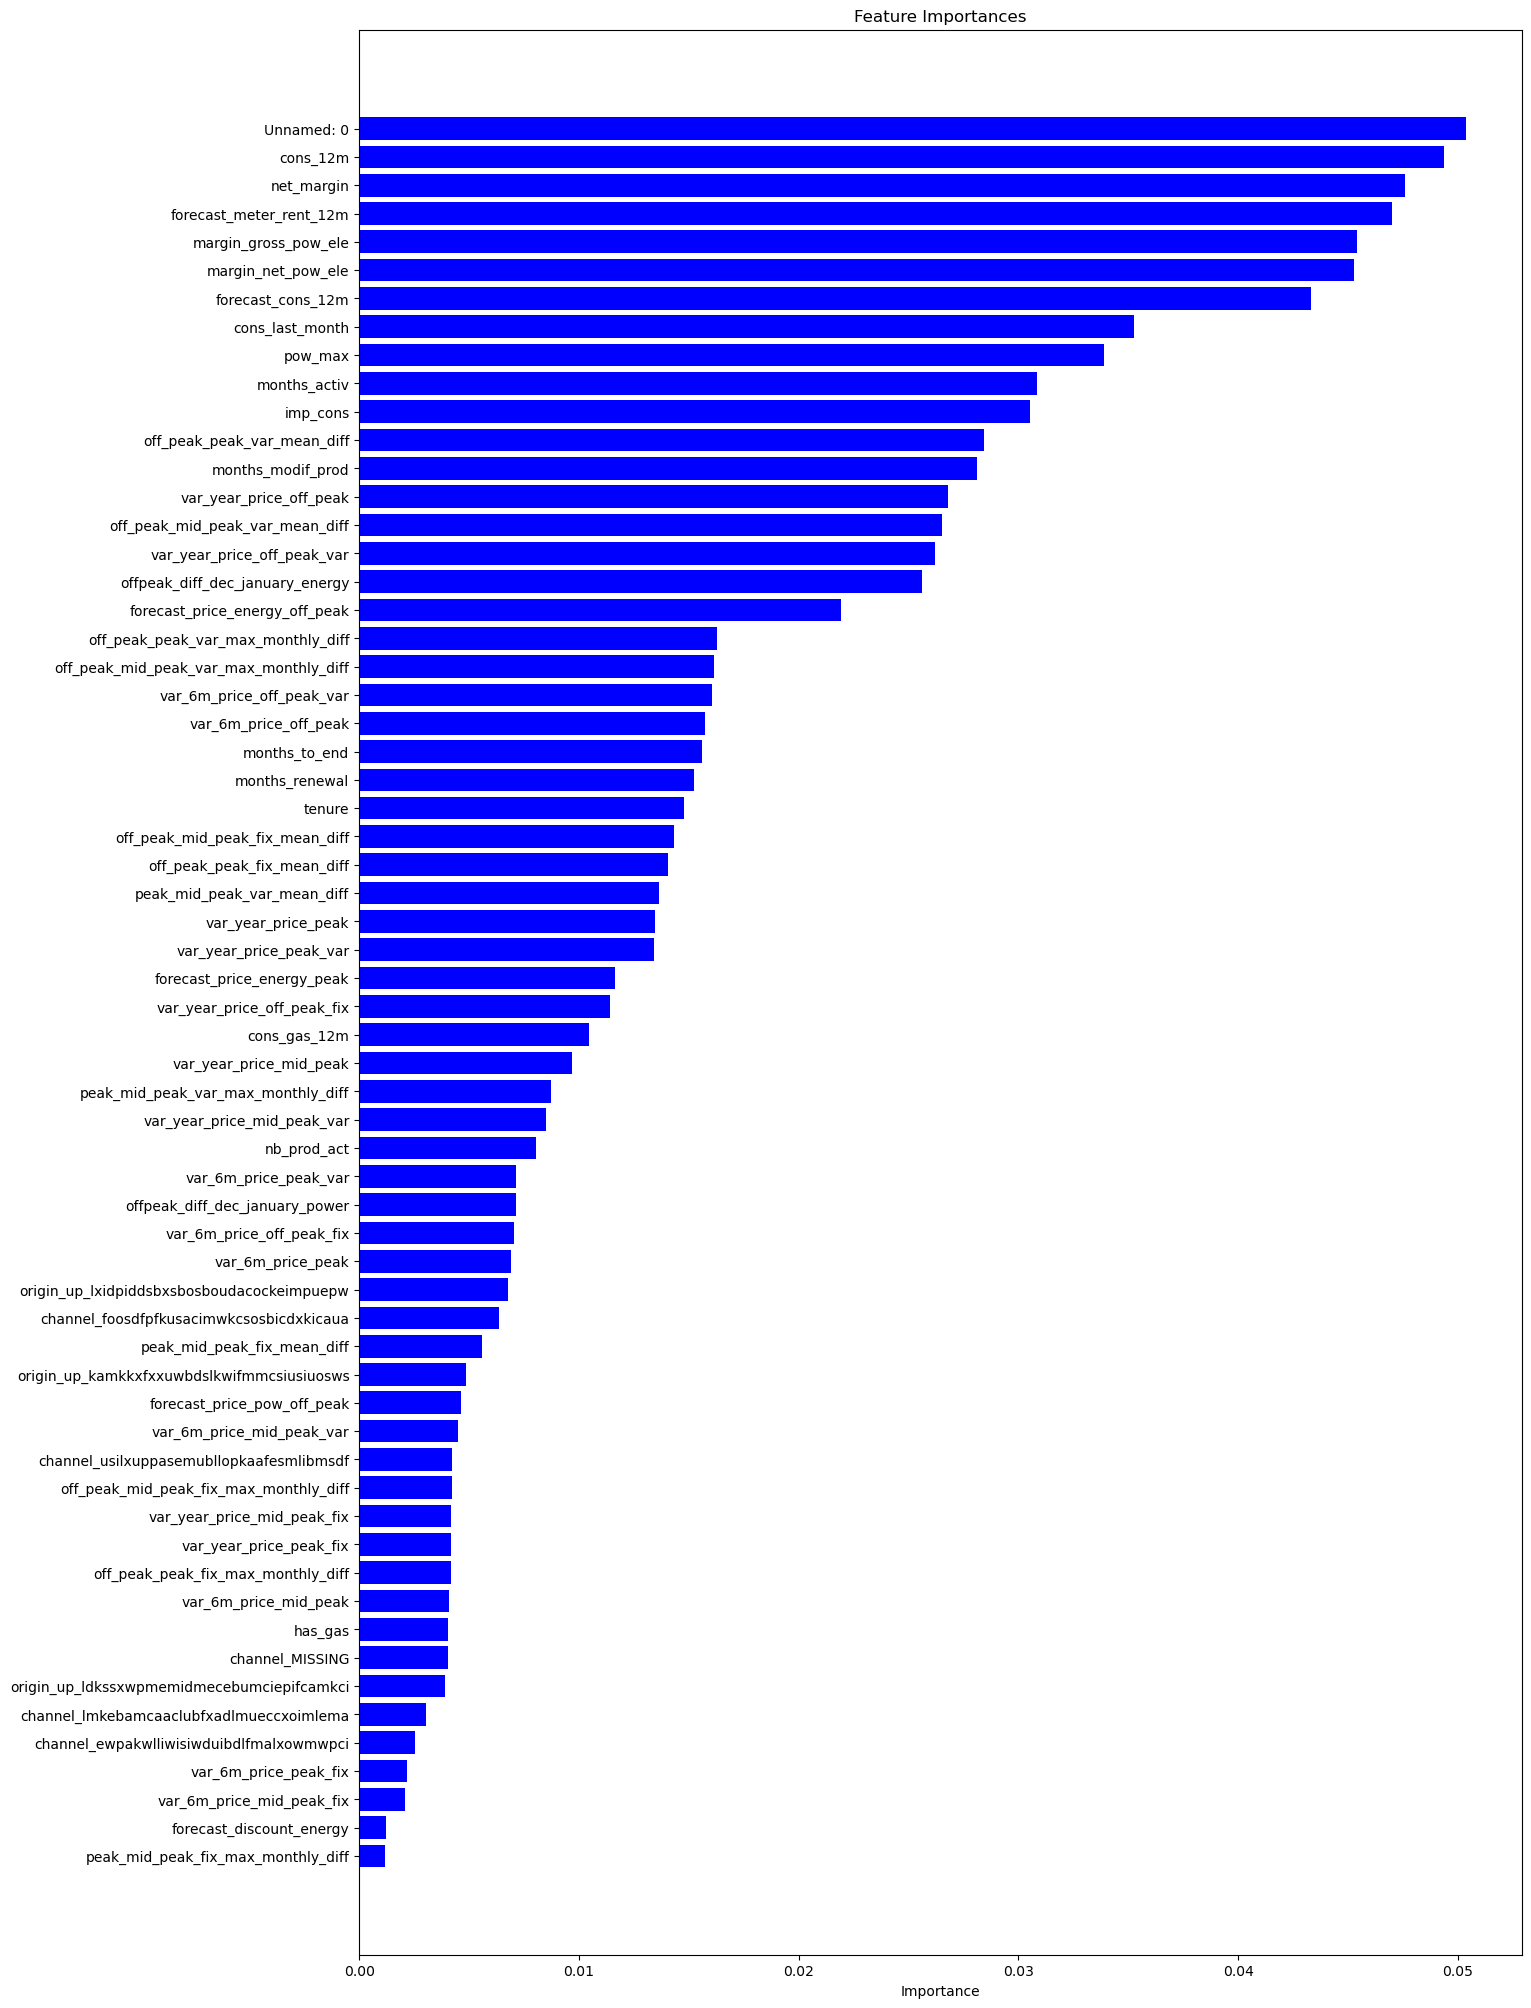

In [60]:
plt.figure(figsize=(15, 25))
plt.title('Feature Importances')
plt.barh(range(len(feature_importances)), feature_importances['importance'], color='b', align='center')
plt.yticks(range(len(feature_importances)), feature_importances['features'])
plt.xlabel('Importance')
plt.show()

In [57]:
proba_predictions = model.predict_proba(X_test)
probabilities = proba_predictions[:,1]

In [61]:
X_test   = X_test.reset_index()
X_test.drop(columns='index', inplace=True)

In [62]:
X_test['churn'] = predictions.tolist()
X_test['churn_probability'] = probabilities.tolist()
X_test.to_csv('out_of_sample_data_with_predictions.csv')